In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
from google.colab import files

In [ ]:
f = files.upload()

Saving chatgpt_reviews.csv to chatgpt_reviews.csv


In [ ]:
df = pd.read_csv("chatgpt_reviews.csv")


In [ ]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [ ]:
df["Ratings"].value_counts()

,count
Ratings,
5,150215
4,22897
1,12083
3,8157
2,3375


In [ ]:
def category(ranking):
  if ranking >=4:
    return "Positive"
  elif ranking ==3:
    return "Neutral"
  else:
    return "Negative"

In [ ]:
df['category'] = df['Ratings'].apply(category)
df.head()

,Review Id,Review,Ratings,Review Date,category
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,Positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,Positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,Positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,Positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,Positive


Sentiment Analysis (Positive, Negative, Neutral)

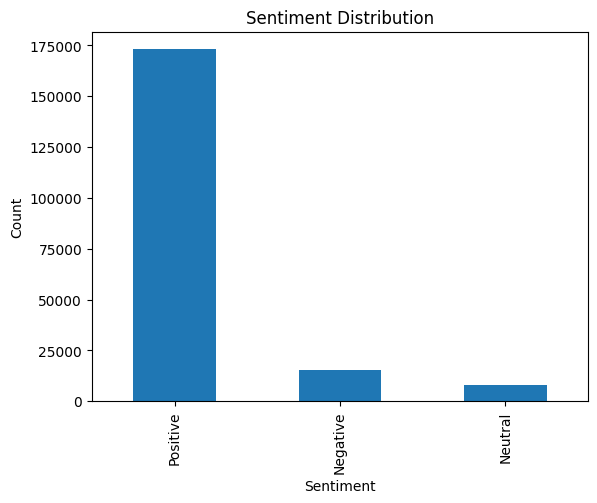

In [ ]:
df['category'].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Issue Identification



In [ ]:
negative_reviews = df[df['category'] == "Negative"]

In [ ]:
sample = negative_reviews.sample(n=50, random_state=42)
sample.head()

,Review Id,Review,Ratings,Review Date,category
1959,a47aded8-a6ea-424c-8334-5a1153d18f6a,how can this be legitimate?,1,2024-08-22 00:49:08,Negative
126898,62ae791e-0a1f-4251-ab27-ac89f23a17b6,App is not working,2,2024-01-17 13:50:08,Negative
52136,475704c1-c56c-4e5b-872b-7251861383c3,"Too many problems for a paid service, too many...",1,2024-06-18 08:52:46,Negative
111783,5f50ed70-6417-4b1b-9f6e-2ea2f5105f39,Kinda not fair for those who dont have phones....,1,2023-08-25 18:52:33,Negative
5393,aead1e8c-b8d1-409e-8eea-03f45cc24955,جيد,1,2024-08-18 15:47:31,Negative


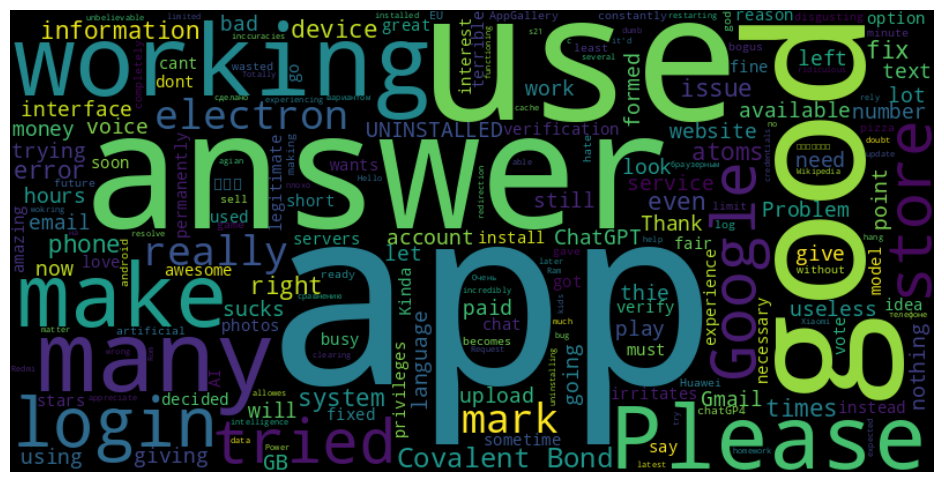

In [ ]:
text_sample = " ".join(str(review) for review in sample["Review"])

wordcloud = WordCloud(width=800, height=400).generate(text_sample)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
df["date"] = pd.to_datetime(df["Review Date"])


In [ ]:
df.head()

,Review Id,Review,Ratings,Review Date,category,date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,Positive,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,Positive,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,Positive,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,Positive,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,Positive,2024-08-23 19:20:39


In [ ]:
monthly = df.groupby([df['date'].dt.to_period('M'), 'category']).size().unstack(fill_value=0)
monthly

category,Negative,Neutral,Positive
date,,,
2023-07,826,339,7118
2023-08,844,309,5648
2023-09,656,271,6666
2023-10,443,216,5165
2023-11,680,332,7707
2023-12,850,358,9167
2024-01,857,327,8129
2024-02,771,300,7677
2024-03,1161,695,13319


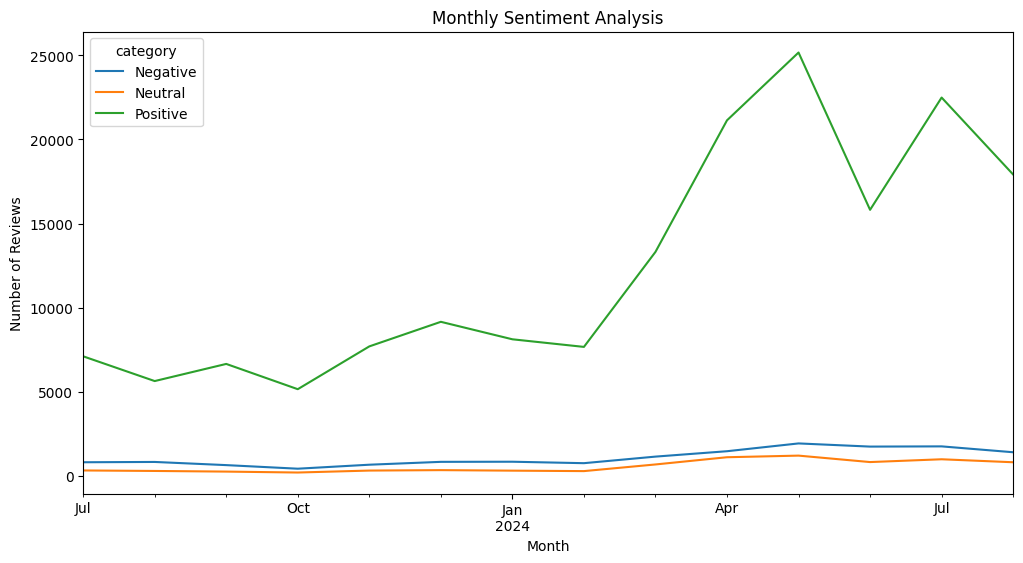

In [ ]:
monthly.plot(figsize=(12,6))
plt.title("Monthly Sentiment Analysis")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()